To implement decoder model architecture, we will need to accomplish following tasks:

1) Text needs to be converted into tokens

2) For step 1, we will need to implement a tokenizer

3) For step 2, we will create a character based tokenizer and train it on data corpus

4) tokenizer should be able to convert text into numbers(encode) and convert numbers back to characters(decode)

5) tokenizer will have its own vocab and dictionaries to perform forward and reverse lookups

6) We will need a dataset which will be converted into iterator and dataloader be created after it. 
Dataloader should create inputs and labels such that labels are 1 position behind the input(DataCollator for Language Modeling in hugging face).

7) We need to create decoder model now

8) First step is to create embedding layer whose input size is equal to vocabulary size and output size is equal to number of dimensions we want to create for each input.

9) Second step is to create positional embeddings whose input size is equal to context length and output isze is equal to model dimension(same as in step 8)

10) add 8+9 and then feed it to decoder block
                                                                                                                                                          
11) Continue with decoder block tomorrow

12) Decoder --> layer norm --> Attention head --> concat attention heads--> add linear layer--> feed forward layer - squeeze and excite with gelu in between (add dropout and layer norm as required)

13) Create decoder layers

14) Finally put linear layer which converts model dimension to vocab dimension for each position

15) train the model ...<<<more to follow tomorrow>>>

## Let us implement character tokenizer

Steps in implementing chracter tokenizer:
1) Reading the text and creating a vocabulary
2) Mapping vocab tokens to ids and then from ids to vocab tokens
3) Encode function that takes text; convert it into tokens and then into token ids
4) Decode function that takes tokenids, converts into tokens and then joins tokens to form a coherent text

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
from pathlib import Path
import sys
from torch.utils.data import Dataset, DataLoader, RandomSampler

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [3]:
try:
    from transformers import AutoTokenizer
    from datasets import load_dataset
except:
    print("datasets/transformers package is not installed. installing it now. Please remember to start kernel once installation is complete")
    !pip install transformers
    !pip install datasets
    print("Please restart your kernel now")

In [4]:
ds = load_dataset("Trelis/tiny-shakespeare")

In [5]:
ds

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

In [6]:
len(ds['train'][0]['Text'])

3131

In [7]:
len_train = len(ds['train'])

In [8]:
for i in range(len_train):
    print(len(ds['train'][i]['Text']))

3131
1703
1614
3199
3159
2872
2969
2847
1930
2451
2507
3046
3122
3081
2701
3265
2478
2750
2796
2550
2863
2410
3173
2218
2813
2562
1264
1708
3239
2945
2417
2488
2554
2601
1802
2767
2743
1029
2009
2165
3295
2541
2435
3013
3128
2843
2930
2428
2502
2964
1997
3116
2622
2794
2849
2636
3142
2763
2656
3038
3090
2896
3239
3070
2438
3158
2773
2050
3261
2886
3234
3076
1406
2902
3065
225
2923
3075
3186
1667
3050
3157
2912
1437
1632
2189
3068
1158
2014
2688
3059
1558
1556
3042
3103
1966
2683
1448
1637
3003
3255
2337
2970
3267
593
2232
2508
3135
3143
2472
2963
3114
3202
3324
3209
3396
2109
2848
2965
3007
2111
2931
3114
3020
3125
2947
2986
3362
2688
1986
2961
1184
2012
3137
2372
2918
2003
3266
1361
1853
2707
3081
3283
3304
2679
3286
1377
1857
3171
3313
3035
3107
1897
3301
3352
3185
1572
1676
2705
3076
2458
3103
2193
3025
2403
1387
1842
3251
3146
905
2399
3387
623
2674
3281
3318
255
3141
3349
3422
3009
2986
3156
3057
3027
3307
2477
2894
62
3238
3228
3113
1558
2635
1339
1676
2985
40
2942
2923
2056
3311

In [9]:
#lets combine all the data together train+test together

In [10]:
ds

DatasetDict({
    train: Dataset({
        features: ['Text'],
        num_rows: 472
    })
    test: Dataset({
        features: ['Text'],
        num_rows: 49
    })
})

In [11]:
df_train = ds['train'].to_pandas()
df_train

,Text
0,"First Citizen:\nBefore we proceed any further,..."
1,"Alack,\nYou are transported by calamity\nThith..."
2,"With a kind of smile,\nWhich ne'er came from t..."
3,"With a kind of smile,\nWhich ne'er came from t..."
4,Your virtue is\nTo make him worthy whose offen...
...,...
467,"To express the like kindness, myself,\nthat ha..."
468,"You are passing welcome,\nAnd so I pray you al..."
469,"You are passing welcome,\nAnd so I pray you al..."
470,"Good morrow, Kate; for that's your name, I hea..."


In [12]:
df_test = ds['test'].to_pandas()
df_test

,Text
0,"TRANIO:\nIs this your speeding? nay, then, goo..."
1,"Sir, list to me:\nI am my father's heir and on..."
2,"And, to cut off all strife, here sit we down:\..."
3,"Now, Licio, to you:\nGood masters, take it not..."
4,"TRANIO:\nPatience, good Katharina, and Baptist..."
5,And yet I come not well.\n\nBAPTISTA:\nAnd yet...
6,"we'll fit him to our turn,--\nAnd he shall be ..."
7,But that his beard grew thin and hungerly\nAnd...
8,"Grumio,\nDraw forth thy weapon, we are beset w..."
9,"But wilt thou make a\nfire, or shall I complai..."


In [13]:
len(df_train), len(df_test)

(472, 49)

In [14]:
df_train.columns, df_test.columns

(Index(['Text'], dtype='object'), Index(['Text'], dtype='object'))

In [15]:
#let us mrge the two datasets together
df = pd.concat([df_train, df_test], axis=0)
df.reset_index(inplace=True, drop=True)
len(df)

521

In [16]:
df

,Text
0,"First Citizen:\nBefore we proceed any further,..."
1,"Alack,\nYou are transported by calamity\nThith..."
2,"With a kind of smile,\nWhich ne'er came from t..."
3,"With a kind of smile,\nWhich ne'er came from t..."
4,Your virtue is\nTo make him worthy whose offen...
...,...
516,What!\nAn advocate for an imposter! hush!\nTho...
517,Our hint of woe\nIs common; every day some sai...
518,The wager?\n\nANTONIO:\nA laughter.\n\nSEBASTI...
519,"GONZALO:\nI assure you, Carthage.\n\nSEBASTIAN..."


In [17]:
shakes_ds = './shakes_ds.csv'
df.to_csv(shakes_ds, index=False)
!ls -ltr

total 169564
drwxrwxr-x  3 ec2-user ec2-user      4096 Feb 22  2025 scripts
-rw-rw-r--  1 ec2-user ec2-user 135751680 Mar 16  2025 brogpt.tar
-rw-rw-r--  1 ec2-user ec2-user  28924927 Mar 22  2025 agnews_train
-rw-rw-r--  1 ec2-user ec2-user   1822708 Mar 22  2025 agnews_test
-rw-rw-r--  1 ec2-user ec2-user    129719 Mar 22  2025 Encoder_MLM.ipynb
drwxrwxr-x 10 ec2-user ec2-user      4096 Apr 13 16:40 encoder-decoder
-rw-rw-r--  1 ec2-user ec2-user   1341374 Apr 25 05:01 shakes_ds.txt
-rw-rw-r--  1 ec2-user ec2-user   1756839 Apr 25 06:20 BroGPT-GPT2Pretrained.ipynb
drwxrwxr-x  3 ec2-user ec2-user      4096 Apr 25 06:34 model_ckpts
-rw-rw-r--  1 ec2-user ec2-user    292466 Apr 25 06:48 BroGPT.ipynb
-rw-rw-r--  1 ec2-user ec2-user   2243707 Apr 25 06:49 BroGPT-GPT2TOK.ipynb
-rw-rw-r--  1 ec2-user ec2-user   1342940 Apr 25 06:50 shakes_ds.csv


In [18]:
df['txt_len'] = df['Text'].apply(lambda x: len(x))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     521 non-null    object
 1   txt_len  521 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 8.3+ KB


In [19]:
df.describe()

,txt_len
count,521.000000
mean,2574.614203
std,693.507375
min,18.000000
25%,2218.000000
50%,2796.000000
75%,3076.000000
max,3586.000000


In [20]:
#While we can read directly from df/csv to create dataset, we will need to break it as irregular intervals
#as we see there is a huge variation in length of indiviual texts
#let us now write the entire text in normal text file. This will help us batch things better without wasting
#on padding tokens

In [21]:
len(df['Text'].to_list())

521

In [22]:
shakes_txt = './shakes_ds.txt'
with open(shakes_txt, 'w') as f:
    for i in range(len(df)):
        f.write(df['Text'].iloc[i])

In [23]:
!head ./shakes_ds.txt

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:


In [24]:
!tail -50  ./shakes_ds.txt

Execute all things; for no kind of traffic
Would I admit; no name of magistrate;
Letters should not be known; riches, poverty,
And use of service, none; contract, succession,
Bourn, bound of land, tilth, vineyard, none;
No use of metal, corn, or wine, or oil;
No occupation; all men idle, all;
And women too, but innocent and pure;
No sovereignty;--

SEBASTIAN:
Yet he would be king on't.

ANTONIO:
The latter end of his commonwealth forgets the
beginning.

GONZALO:
All things in common nature should produce
Without sweat or endeavour: treason, felony,
Sword, pike, knife, gun, or need of any engine,
Would I not have; but nature should bring forth,
Of its own kind, all foison, all abundance,
To feed my innocent people.

SEBASTIAN:
No marrying 'mong his subjects?

ANTONIO:
None, man; all idle: whores and knaves.

GONZALO:
I would with such perfection govern, sir,
To excel the golden age.

SEBASTIAN:
God save his majesty!

ANTONIO:
Long live Gonzalo!

GONZALO:
And,--do you mark me, sir?

ALON

In [25]:
vocab_text = Path('./shakes_ds.txt').read_text()

In [26]:
#lets try reading from text file in pythonic way
print(vocab_text[0:200])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you


In [27]:
tokenizer = AutoTokenizer.from_pretrained("gpt2-medium")

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [28]:
toks = tokenizer.encode("Shaheer")
toks

[2484, 64, 258, 263]

In [29]:
tokenizer.decode(toks) 
# Can it really decode me lol!
# Dude dont take it on heart. Its just converting integers to text thats it bro

'Shaheer'

In [30]:
tokenizer("Shaheer")

{'input_ids': [2484, 64, 258, 263], 'attention_mask': [1, 1, 1, 1]}

In [31]:
text = "This is a beautiful day"
text

'This is a beautiful day'

In [32]:
enc = tokenizer.encode(text, return_tensors='pt')
enc, enc.shape

(tensor([[1212,  318,  257, 4950, 1110]]), torch.Size([1, 5]))

In [33]:
dec = tokenizer.decode(enc.squeeze().tolist())
dec

'This is a beautiful day'

In [34]:
tokenizer

GPT2Tokenizer(name_or_path='gpt2-medium', vocab_size=50257, model_max_length=1024, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<|endoftext|>', 'eos_token': '<|endoftext|>', 'unk_token': '<|endoftext|>'}, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
})

In [35]:
class Embed(nn.Module):
    def __init__(self, vocab_size, embed_dim, ctx_len, do, device):
        super().__init__()
        self.tok_layer = nn.Embedding(vocab_size, embed_dim)
        self.pos_layer = nn.Embedding(ctx_len, embed_dim)
        self.norm_do = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(do)
            )
        self.device = device
        self.ctx_len = ctx_len

    def forward(self, inp):
        inp = inp.to(self.device)
        tok_embed = self.tok_layer(inp)
        len_inp = inp.shape[-1]
        try:
            assert len_inp <= self.ctx_len
        except:
            print("Err..Errr. Error...Bro..Length of supplied text exceeds context length defined.Exiting the program now")
            sys.exit(1)
        pos_range = torch.arange(0, len_inp).unsqueeze(0)
        pos_range = pos_range.to(self.device)
        pos_embed = self.pos_layer(pos_range)
        embed_tok_pos = tok_embed + pos_embed
        embed_out = self.norm_do(embed_tok_pos)
        return embed_out

In [36]:
device

'cpu'

In [37]:
embed_mod = Embed(vocab_size=50257, embed_dim=768, ctx_len=64, do=0.1, device=device)
embed_mod

Embed(
  (tok_layer): Embedding(50257, 768)
  (pos_layer): Embedding(64, 768)
  (norm_do): Sequential(
    (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.1, inplace=False)
  )
)

In [38]:
text_1 = "My name is Anthony Gonsalvez. Main duniya mein akela hoon."
text_1

'My name is Anthony Gonsalvez. Main duniya mein akela hoon.'

In [39]:
text_2 = "My name is Anthony Gonsalvez. Main duniya mein akela hoon. Dil bhi hai khaali ghar bhi khaali isme rahegi koi kismatwaali are jise meri yaad aaye jab chahe chali aaye. Hoon yaaro ka main yaar dushmanon ka dshman de dana dan john johnny janardan tara ram pam pam po"
text_2, len(text_2)

('My name is Anthony Gonsalvez. Main duniya mein akela hoon. Dil bhi hai khaali ghar bhi khaali isme rahegi koi kismatwaali are jise meri yaad aaye jab chahe chali aaye. Hoon yaaro ka main yaar dushmanon ka dshman de dana dan john johnny janardan tara ram pam pam po',
 264)

In [40]:
toks_1 = tokenizer.encode(text_1, return_tensors='pt')
toks_1, toks_1.shape

(tensor([[ 3666,  1438,   318,  9953,   402,   684,   282, 33425,    13,  8774,
          12574, 21008,   502,   259,   257,   365,  5031,   289,  2049,    13]]),
 torch.Size([1, 20]))

In [41]:
toks_1_embed = embed_mod(toks_1)
toks_1_embed, toks_1_embed.shape

(tensor([[[ 0.0000,  0.4085, -0.9734,  ...,  1.1032, -1.4788, -0.4696],
          [ 0.2911,  0.6730, -0.4500,  ...,  0.3613,  0.5594, -1.0898],
          [-0.1153, -1.4501,  0.0222,  ...,  1.8740,  0.0000, -2.0048],
          ...,
          [ 0.3271,  2.3077,  0.2875,  ...,  1.5559, -0.0796, -0.2141],
          [-0.5213, -0.6444, -1.8202,  ...,  0.0717, -1.1665, -0.0000],
          [ 0.4703,  0.3105, -0.3543,  ..., -1.3620,  0.7181,  1.4589]]],
        grad_fn=<MulBackward0>),
 torch.Size([1, 20, 768]))

In [42]:
toks_2 = tokenizer.encode(text_2, return_tensors='pt')
toks_2, toks_2.shape

(tensor([[ 3666,  1438,   318,  9953,   402,   684,   282, 33425,    13,  8774,
          12574, 21008,   502,   259,   257,   365,  5031,   289,  2049,    13,
          29328,   275,  5303,   387,    72,   479,  3099,  7344,   308,  9869,
            275,  5303,   479,  3099,  7344,   318,  1326,  2179,   258, 12397,
            479, 23013,   479,  1042,   265, 10247,  7344,   389,   474,   786,
           4017,    72, 21349,   324,   257, 48822, 33896, 17792,   258,   442,
           7344,   257, 48822,    13,   367,  2049, 21349, 12022, 38387,  1388,
          21349,   283,   288,  1530,   805,   261, 38387,   288,  1477,   805,
            390,   288,  2271, 46078, 45610, 45610,  3281, 42897,   446,   272,
            256,  3301, 15770,   279,   321,   279,   321,   745]]),
 torch.Size([1, 98]))

In [43]:
#This should error out as tokenized length is greater than context length
toks_2_embed = embed_mod(toks_2)
toks_2_embed, toks_2_embed.shape

Err..Errr. Error...Bro..Length of supplied text exceeds context length defined.Exiting the program now


SystemExit: 1

/home/ec2-user/anaconda3/envs/pytorch_p310/lib/python3.10/site-packages/IPython/core/interactiveshell.py:3587: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [44]:
class Attention(nn.Module):
    def __init__(self, embed_dim, k_dim, do, device):
        super().__init__()
        self.embed_dim = embed_dim
        self.k_dim = k_dim
        self.query = nn.Linear(embed_dim, k_dim)
        self.key = nn.Linear(embed_dim, k_dim)
        self.value = nn.Linear(embed_dim, k_dim)
        self.att_do = nn.Dropout(do)
        self.device = device

    def forward(self, inputs):
        bs = inputs.shape[0]
        num_toks = inputs.shape[1]
        q = self.query(inputs)
        k = self.key(inputs)
        v = self.value(inputs)
        qk = (q@k.transpose(1, 2))/(self.k_dim**0.5)
        t1 = torch.tril(torch.ones(bs, num_toks, num_toks))
        mask = torch.where(t1 == 0, -torch.inf, 0.0)
        mask = mask.to(self.device)
        qk_m = qk + mask
        qk_m_smax = torch.softmax(qk_m, dim=-1)
        qk_m_smax_do = self.att_do(qk_m_smax)
        qkv = qk_m_smax_do@v
        return qkv

In [45]:
att_mod = Attention(embed_dim=768, k_dim=64, do=0.1, device=device)
att_mod

Attention(
  (query): Linear(in_features=768, out_features=64, bias=True)
  (key): Linear(in_features=768, out_features=64, bias=True)
  (value): Linear(in_features=768, out_features=64, bias=True)
  (att_do): Dropout(p=0.1, inplace=False)
)

In [46]:
att_mod_out = att_mod(toks_1_embed)
att_mod_out, att_mod_out.shape

(tensor([[[ 4.1303e-02,  1.0158e+00,  1.1709e+00,  ..., -2.4392e-01,
           -3.0529e-01,  5.9889e-01],
          [-1.4560e-01,  9.7840e-01,  3.7404e-01,  ..., -1.9139e-01,
           -3.9640e-01,  2.0580e-01],
          [-2.7185e-01,  9.4546e-01,  3.4275e-01,  ..., -2.0759e-01,
           -2.0034e-01, -4.5351e-03],
          ...,
          [-1.9736e-01,  1.5258e-01, -3.3029e-02,  ..., -7.4923e-03,
            2.3965e-01, -5.0653e-02],
          [-4.2956e-02, -2.7587e-04,  6.0210e-02,  ..., -8.9066e-02,
            1.9306e-01, -1.3296e-01],
          [-1.6013e-01,  6.1410e-02,  3.9587e-02,  ...,  1.0310e-01,
            3.1342e-01, -1.3308e-01]]], grad_fn=<UnsafeViewBackward0>),
 torch.Size([1, 20, 64]))

In [47]:
#so things are working good

In [48]:
class Attention_Block(nn.Module):
    def __init__(self, num_heads, embed_dim, k_dim, do, device):
        super().__init__()
        self.num_heads = num_heads
        self.heads_list = [Attention(embed_dim, k_dim, do, device) for i in range(num_heads)]
        self.heads = nn.ModuleList(self.heads_list)
        self.lin_do = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.Dropout(do)
        )

    def forward(self, inputs):
        heads_list_out = [head(inputs) for head in self.heads]
        att_head = torch.cat(heads_list_out, dim=-1)
        att_head_out = self.lin_do(att_head)
        return att_head_out

In [49]:
att_blk = Attention_Block(num_heads=12, embed_dim=768, k_dim=64, do=0.1, device=device)
att_blk

Attention_Block(
  (heads): ModuleList(
    (0-11): 12 x Attention(
      (query): Linear(in_features=768, out_features=64, bias=True)
      (key): Linear(in_features=768, out_features=64, bias=True)
      (value): Linear(in_features=768, out_features=64, bias=True)
      (att_do): Dropout(p=0.1, inplace=False)
    )
  )
  (lin_do): Sequential(
    (0): Linear(in_features=768, out_features=768, bias=True)
    (1): Dropout(p=0.1, inplace=False)
  )
)

In [50]:
att_blk_out = att_blk(toks_1_embed)
att_blk_out, att_blk_out.shape

(tensor([[[-0.4419,  0.2674,  0.4607,  ..., -0.7580,  0.0000,  0.1935],
          [-0.2422,  0.1716, -0.0371,  ..., -0.5015, -0.1450,  0.0099],
          [-0.4291, -0.1990, -0.1366,  ..., -0.2676, -0.2382, -0.2303],
          ...,
          [-0.0301,  0.0370, -0.1886,  ..., -0.0273, -0.1151, -0.1222],
          [-0.0169,  0.0452, -0.1006,  ..., -0.0622, -0.0000, -0.0543],
          [ 0.0997,  0.0191, -0.1753,  ..., -0.0594, -0.1113, -0.0340]]],
        grad_fn=<MulBackward0>),
 torch.Size([1, 20, 768]))

In [51]:
class Transformer_Block(nn.Module):
    def __init__(self, num_heads, embed_dim, k_dim, do, device):
        super().__init__()
        self.MHA = Attention_Block(num_heads, embed_dim, k_dim, do, device)
        self.ff = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, embed_dim*4),
            nn.GELU(),
            nn.Linear(embed_dim*4, embed_dim),
            nn.LayerNorm(embed_dim),
            nn.Dropout(do)
            )

    def forward(self, inputs):
        inp_start_att_block = inputs
        x = self.MHA(inputs)
        x = x + inp_start_att_block

        inp_start_ff_block = x
        x = self.ff(x)
        x = x + inp_start_ff_block
        return x


In [52]:
trans_blk = Transformer_Block(num_heads=12, embed_dim=768, k_dim=64, do=0.1, device=device)
trans_blk

Transformer_Block(
  (MHA): Attention_Block(
    (heads): ModuleList(
      (0-11): 12 x Attention(
        (query): Linear(in_features=768, out_features=64, bias=True)
        (key): Linear(in_features=768, out_features=64, bias=True)
        (value): Linear(in_features=768, out_features=64, bias=True)
        (att_do): Dropout(p=0.1, inplace=False)
      )
    )
    (lin_do): Sequential(
      (0): Linear(in_features=768, out_features=768, bias=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (ff): Sequential(
    (0): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (1): Linear(in_features=768, out_features=3072, bias=True)
    (2): GELU(approximate='none')
    (3): Linear(in_features=3072, out_features=768, bias=True)
    (4): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (5): Dropout(p=0.1, inplace=False)
  )
)

In [53]:
trans_blk_out = trans_blk(toks_1_embed)
trans_blk_out, trans_blk_out.shape

(tensor([[[ 2.7230,  1.0326, -2.6504,  ...,  2.6139, -0.6622, -1.1536],
          [ 0.6199,  3.0371, -0.0089,  ...,  0.7524,  0.8355, -1.0670],
          [-0.1153, -1.4357, -1.7103,  ...,  1.0187, -0.3766, -2.3469],
          ...,
          [ 0.7630,  3.2830,  0.5267,  ...,  1.9345, -2.5300, -0.2858],
          [ 0.2023, -1.1704, -2.2209,  ...,  0.1698, -0.0116, -1.9023],
          [-1.7784, -1.1879, -2.7021,  ..., -0.5578,  1.4075,  1.4589]]],
        grad_fn=<AddBackward0>),
 torch.Size([1, 20, 768]))

In [54]:
class BroGPT(nn.Module):
    def __init__(self, num_layers, num_heads, vocab_size, embed_dim, k_dim, ctx_len, do, device):
        super().__init__()
        self.emb = Embed(vocab_size, embed_dim, ctx_len, do, device)
        self.layer_list = [Transformer_Block(num_heads, embed_dim, k_dim, do, device) for i in range(num_layers)]
        self.layers = nn.Sequential(*self.layer_list)
        self.embed_vocab = nn.Linear(embed_dim, vocab_size)

    def forward(self, inputs):
        x = self.emb(inputs)
        x = self.layers(x)
        x = self.embed_vocab(x)
        return x

In [55]:
tokenizer.vocab_size

50257

In [56]:
num_layers = 6
num_heads = 4
vocab_size = tokenizer.vocab_size
embed_dim = 256
k_dim = 64
ctx_len = 256
do = 0.1

In [57]:
brogpt = BroGPT(num_layers, num_heads, vocab_size, embed_dim, k_dim, ctx_len, do, device)
brogpt

BroGPT(
  (emb): Embed(
    (tok_layer): Embedding(50257, 256)
    (pos_layer): Embedding(256, 256)
    (norm_do): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Transformer_Block(
      (MHA): Attention_Block(
        (heads): ModuleList(
          (0-3): 4 x Attention(
            (query): Linear(in_features=256, out_features=64, bias=True)
            (key): Linear(in_features=256, out_features=64, bias=True)
            (value): Linear(in_features=256, out_features=64, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (ff): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=1024, bias=True)
    

In [58]:
sum([p.numel() for p in brogpt.parameters()])

30586449

In [59]:
brogpt_out = brogpt(toks_1)
brogpt_out, brogpt_out.shape

(tensor([[[-0.4640,  0.6386, -0.2364,  ...,  1.7298, -0.3776,  2.5732],
          [-2.5718,  2.0829, -0.6480,  ..., -1.4193, -2.6837,  1.7139],
          [ 0.1406,  1.5137, -0.2943,  ...,  2.0710,  0.4057,  0.5131],
          ...,
          [-0.7870,  0.1811,  1.6554,  ...,  1.0699, -1.1145,  2.2290],
          [-0.3656,  1.1391, -0.1209,  ..., -2.2856, -2.4095, -1.4886],
          [-0.5502,  1.3415, -1.2468,  ...,  1.2830, -1.9995,  0.1259]]],
        grad_fn=<ViewBackward0>),
 torch.Size([1, 20, 50257]))

In [60]:
# let us test it out again
text = "Elon Musk is building next "
input_ids = tokenizer.encode(text, return_tensors='pt')
input_ids, input_ids.shape

(tensor([[ 9527,   261, 20119,   318,  2615,  1306,   220]]),
 torch.Size([1, 7]))

In [61]:
input_ids = input_ids.to(device)
brogpt.to(device)

BroGPT(
  (emb): Embed(
    (tok_layer): Embedding(50257, 256)
    (pos_layer): Embedding(256, 256)
    (norm_do): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Transformer_Block(
      (MHA): Attention_Block(
        (heads): ModuleList(
          (0-3): 4 x Attention(
            (query): Linear(in_features=256, out_features=64, bias=True)
            (key): Linear(in_features=256, out_features=64, bias=True)
            (value): Linear(in_features=256, out_features=64, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (ff): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=1024, bias=True)
    

In [62]:
out = brogpt(input_ids)
out, out.shape

(tensor([[[-0.0714,  0.6043,  0.4998,  ...,  0.7081, -3.3562,  1.8745],
          [-1.8675,  1.0282, -2.5321,  ..., -2.2175, -1.5035,  1.1066],
          [-1.4717,  1.4661, -0.1489,  ..., -0.7054, -0.2204, -0.7785],
          ...,
          [ 0.9322,  4.2108,  1.1964,  ...,  2.5887, -1.8030,  1.9131],
          [-1.4218,  0.7134,  2.3108,  ..., -2.0638, -4.7787,  1.7869],
          [ 1.7282,  0.2265,  0.6119,  ...,  0.9926, -0.8002,  2.6045]]],
        grad_fn=<ViewBackward0>),
 torch.Size([1, 7, 50257]))

In [63]:
ids = torch.argmax(out, dim=-1)
ids = ids.squeeze().tolist()
dec = tokenizer.decode(ids)
print(dec)

pretty were consequence arr homegrown entrance Such


In [64]:
len(dec)

51

In [65]:
#lets simulate this in batch format

In [66]:
inp = torch.randint(low=0, high=64, size=(4, 8))
inp = inp.to(device)

In [67]:
inp.shape

torch.Size([4, 8])

In [68]:
out = brogpt(inp)
out, out.shape

(tensor([[[ 1.0008,  1.4774,  0.7733,  ...,  1.7429, -3.6793, -3.4947],
          [ 1.2908,  0.7338,  2.6386,  ...,  2.3898, -3.8385,  0.5792],
          [-2.3830,  1.3976,  2.5082,  ...,  0.0960, -0.9199, -0.5196],
          ...,
          [-1.1308,  3.3625,  1.6939,  ..., -0.4746, -4.7379, -0.1134],
          [-2.4173,  1.7176,  0.3907,  ..., -0.2710, -2.3032,  0.9313],
          [ 1.7248,  1.9320,  2.5037,  ...,  0.3149, -0.2883,  1.6333]],
 
         [[ 0.6280,  4.1276, -0.2928,  ...,  4.2603, -1.7714, -0.8921],
          [-0.7361,  1.3204, -1.1640,  ...,  0.3933, -1.8224,  0.8096],
          [-1.2121,  1.4105,  0.1979,  ...,  3.0176,  0.5154, -0.7029],
          ...,
          [-1.2846,  0.5061,  0.9838,  ..., -0.5952, -3.4582,  1.3255],
          [ 0.5314,  1.0451, -2.1982,  ...,  0.8739, -0.9266,  2.8428],
          [ 1.1373, -0.2411,  1.4977,  ..., -0.5192,  0.1758,  3.0352]],
 
         [[ 0.1318,  1.1772,  1.8992,  ...,  3.8739,  0.6482, -2.1108],
          [-0.0361,  3.1460,

In [69]:
#so this is working in batch format

In [70]:
ids = torch.argmax(out, dim=-1)
for i in ids:
    dec = tokenizer.decode(i.squeeze().tolist())
    print(dec)

Ref sketch"></bang NE Ventures breed fluffy
JUST usability injustice Illusionl 235 Jordanl
ryu straightforwardShould NUM Agency dimin intraaging
 flowering bowlingaunts endorsing inoc grind legislatorreditation


### Next tasks:
1) Create dataloader
2) Implement training loop and train the model(Use AWS if required)
3) Create a probabilistic decoding mechanism

In [71]:
torch.tensor(tokenizer.encode("I love sea beaches"))

tensor([   40,  1842,  5417, 25585])

In [72]:
tokenizer.encode("I love sea beaches", return_tensors='pt').shape

torch.Size([1, 4])

In [73]:
len_vocab = len(vocab_text.split())
len_vocab, int(len_vocab/256)

(243276, 950)

In [74]:
toks_ds = []
bs = 256
vocab_text_split = vocab_text.split()
bs_chunks = int(len(vocab_text_split)/bs)
for i in range(bs_chunks):
    start_indx = i*bs
    end_indx = start_indx + bs
    chunk = ' '.join(vocab_text_split[start_indx:end_indx])
    print(chunk)
    toks = tokenizer.encode(chunk)
    toks_ds.extend(toks)

First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather to die than to famish? All: Resolved. resolved. First Citizen: First, you know Caius Marcius is chief enemy to the people. All: We know't, we know't. First Citizen: Let us kill him, and we'll have corn at our own price. Is't a verdict? All: No more talking on't; let it be done: away, away! Second Citizen: One word, good citizens. First Citizen: We are accounted poor citizens, the patricians good. What authority surfeits on would relieve us: if they would yield us but the superfluity, while it were wholesome, we might guess they relieved us humanely; but they think we are too dear: the leanness that afflicts us, the object of our misery, is as an inventory to particularise their abundance; our sufferance is a gain to them Let us revenge this with our pikes, ere we become rakes: for the gods know I speak this in hunger for bread, not in thirst for revenge. Second Cit

In [75]:
len(toks_ds)

354262

In [76]:
class Bro_Shake_DS(Dataset):
    def __init__(self, vocab_text, tokenizer, bs=256):
        super().__init__()
        self.data = vocab_text
        self.bs = bs
        self.tokenizer = tokenizer
        self.toks_ds = []
        vocab_text_split = vocab_text.split()
        bs_chunks = int(len(vocab_text_split)/bs)
        for i in range(bs_chunks):
            start_indx = i*bs
            end_indx = start_indx + bs
            chunk = ' '.join(vocab_text_split[start_indx:end_indx])
            toks = tokenizer.encode(chunk)
            self.toks_ds.extend(toks)

    def __len__(self):
        return int((len(self.toks_ds) - self.bs)/self.bs)

    def __getitem__(self, idx):
        idx = idx * self.bs
        assert idx < len(self.data) - self.bs
        x = torch.tensor(self.toks_ds[idx:idx+self.bs])
        y = torch.tensor(self.toks_ds[idx+1:idx+1+self.bs])

        return x, y

In [77]:
len(vocab_text)

1341374

In [78]:
ds = Bro_Shake_DS(vocab_text, tokenizer)
ds

In [80]:
len(ds) 

1382

In [81]:
dl = DataLoader(ds, shuffle=False, batch_size=32)

In [82]:
len(dl)

44

In [83]:
len(dl.dataset)

1382

In [84]:
n=1
for t, l in dl:
    print(f'Sample no: {n}')
    print(f'Text: {t}\n')
    print(f'Label: {l}\n')
    print(t.shape, l.shape)
    n += 1
    if n>10:
        break


Sample no: 1
Text: tensor([[ 5962, 22307,    25,  ...,   385,  1526, 28599],
        [   30,  1439,    25,  ...,   679,   338,   530],
        [ 5508,  1576,    25,  ...,  1555,   810,   517],
        ...,
        [35253,    82,   356,  ...,    83,  3872,    11],
        [39675,  2973, 14210,  ...,   351, 49207,   406],
        [  433,  3754,    30,  ...,  1081,   314,  4724]])

Label: tensor([[22307,    25,  7413,  ...,  1526, 28599,    30],
        [ 1439,    25, 12914,  ...,   338,   530,  5508],
        [ 1576,    25,   561,  ...,   810,   517, 32743],
        ...,
        [   82,   356,   423,  ...,  3872,    11, 39675],
        [ 2973, 14210,  2740,  ..., 49207,   406,   433],
        [ 3754,    30, 18805,  ...,   314,  4724,    11]])

torch.Size([32, 256]) torch.Size([32, 256])
Sample no: 2
Text: tensor([[   11,  1526, 28599,  ...,    11,   502,  3436],
        [    0,   787,   345,  ..., 12936,    25,  1892],
        [ 3295, 12216,   257,  ...,  1350,  1547,    11],
        ...

In [85]:
t, l = t.to(device), l.to(device)
t.shape, l.shape

(torch.Size([32, 256]), torch.Size([32, 256]))

In [86]:
embed = Embed(vocab_size, embed_dim, ctx_len, do, device)
embed.to(device)

Embed(
  (tok_layer): Embedding(50257, 256)
  (pos_layer): Embedding(256, 256)
  (norm_do): Sequential(
    (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    (1): Dropout(p=0.1, inplace=False)
  )
)

In [87]:
e_t = embed(t)
e_t.shape

torch.Size([32, 256, 256])

In [88]:
epochs = 1
lr = 0.0006
fn_loss = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(brogpt.parameters(), lr=lr)

In [89]:
sum([p.numel() for p in brogpt.parameters()])

30586449

In [90]:
#we will not train in cpu. we will train in gpu using sagemaker

In [91]:
# TODO: Import any packages that you might need
#importing the "King" library :P
import sagemaker
import boto3
from sagemaker.inputs import TrainingInput

#sagemaker pytorch container estimator related libraries
from sagemaker.pytorch import PyTorch
from sagemaker.pytorch import PyTorchModel


from sagemaker.estimator import Estimator
from sagemaker.model import Model
from sagemaker.predictor import Predictor

#general utility imports
import os
import glob
import pandas as pd
import numpy as np
import random

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/ec2-user/.config/sagemaker/config.yaml


In [92]:
#Sagemaker related commands
sess = sagemaker.Session()
role = sagemaker.get_execution_role()
region = sess.boto_region_name
bucket = sess.default_bucket()
sess, role, region, bucket

(<sagemaker.session.Session at 0x7fd0be7ef1f0>,
 'arn:aws:iam::191013407134:role/service-role/AmazonSageMaker-ExecutionRole-20250124T222384',
 'us-east-1',
 'sagemaker-us-east-1-191013407134')

In [93]:
%pwd

'/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT'

In [94]:
S3_LOC = f's3://{bucket}/gpt_train/dataset/'
S3_LOC

's3://sagemaker-us-east-1-191013407134/gpt_train/dataset/'

In [95]:
#!aws s3 cp ./shakes_ds.txt {S3_LOC}

In [96]:
!aws s3 ls --recursive {S3_LOC}

2025-02-26 05:00:50   27728622 gpt_train/dataset/reuters/reuters_ds.csv
2025-02-20 18:20:57    1341374 gpt_train/dataset/shakes_ds.txt


In [97]:
# let us get image uri
training_image_uri = sagemaker.image_uris.retrieve(
    framework='pytorch', 
    version='2.0',
    instance_type='ml.g4dn.xlarge',
    region=region,
    py_version='py310',
    image_scope='training'
)
print(training_image_uri)

763104351884.dkr.ecr.us-east-1.amazonaws.com/pytorch-training:2.0-gpu-py310


In [98]:
train_uri = f'{S3_LOC}'
train_uri

's3://sagemaker-us-east-1-191013407134/gpt_train/dataset/'

In [99]:
s3_inp_tr = TrainingInput(
    s3_data = train_uri
    )
s3_inp_tr

In [100]:
data_channels = {
    'train': s3_inp_tr
    }
data_channels

{'train': <sagemaker.inputs.TrainingInput at 0x7fd08b5066b0>}

In [101]:
objective_metric_name = "average training loss"
objective_type = "Minimize"
metric_definitions = [{"Name": "average training loss", "Regex": "Average loss: ([0-9\\.]+)"},
                      {"Name": "Perplexity", "Regex": "Perplexity: ([0-9\\.]+)"}]
objective_metric_name, objective_type, metric_definitions

('average training loss',
 'Minimize',
 [{'Name': 'average training loss', 'Regex': 'Average loss: ([0-9\\.]+)'},
  {'Name': 'Perplexity', 'Regex': 'Perplexity: ([0-9\\.]+)'}])

In [110]:
hparams = {
    'bs': 32,
    'lrate': 0.0006,
    'num_epochs': 40,
    'do': 0.1,
    'block_size': 256,
    'environ': 'aws',
    'num_layers': 6,
    'num_heads': 4,
    'embed_dim': 256,
    'k_dim': 64,
    'ctx_len': 256
}
hparams

{'bs': 32,
 'lrate': 0.0006,
 'num_epochs': 40,
 'do': 0.1,
 'block_size': 256,
 'environ': 'aws',
 'num_layers': 6,
 'num_heads': 4,
 'embed_dim': 256,
 'k_dim': 64,
 'ctx_len': 256}

In [106]:
ic=1
i_type = "ml.g4dn.xlarge"
ic, i_type

(1, 'ml.g4dn.xlarge')

In [107]:
%pwd

'/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT'

In [108]:
est_brogpt = Estimator(
    image_uri=training_image_uri,
    role=role,
    source_dir='./scripts',
    entry_point='train-gpt2tok.py',
    instance_count=ic,
    instance_type=i_type,
    base_job_name='brogpt-train',
    hyperparameters=hparams,
    metric_definitions=metric_definitions,
    objective_type=objective_type,
    objective_metric_name=objective_metric_name
)

est_brogpt.fit(
    inputs=data_channels,
    wait=True
)

INFO:sagemaker:Creating training-job with name: brogpt-train-2026-04-25-06-59-20-750


2026-04-25 06:59:22 Starting - Starting the training job...
2026-04-25 06:59:37 Starting - Preparing the instances for training...
2026-04-25 07:00:02 Downloading - Downloading input data...
2026-04-25 07:00:33 Downloading - Downloading the training image..................
2026-04-25 07:03:50 Training - Training image download completed. Training in progress...bash: cannot set terminal process group (-1): Inappropriate ioctl for device
bash: no job control in this shell
2026-04-25 07:04:01,942 sagemaker-training-toolkit INFO     Imported framework sagemaker_pytorch_container.training
2026-04-25 07:04:01,963 sagemaker-training-toolkit INFO     No Neurons detected (normal if no neurons installed)
2026-04-25 07:04:01,974 sagemaker_pytorch_container.training INFO     Block until all host DNS lookups succeed.
2026-04-25 07:04:01,981 sagemaker_pytorch_container.training INFO     Invoking user training script.
2026-04-25 07:04:04,022 sagemaker-training-toolkit INFO     No Neurons detected (no

In [112]:
est_brogpt.model_data

's3://sagemaker-us-east-1-191013407134/brogpt-train-2026-04-25-06-59-20-750/output/model.tar.gz'

In [113]:
est_brogpt.latest_training_job.describe()['FinalMetricDataList']

[{'MetricName': 'Perplexity',
  'Value': 1.0619401931762695,
  'Timestamp': datetime.datetime(2026, 4, 25, 7, 18, 23, tzinfo=tzlocal())},
 {'MetricName': 'average training loss',
  'Value': 0.0600975826382637,
  'Timestamp': datetime.datetime(2026, 4, 25, 7, 18, 23, tzinfo=tzlocal())}]

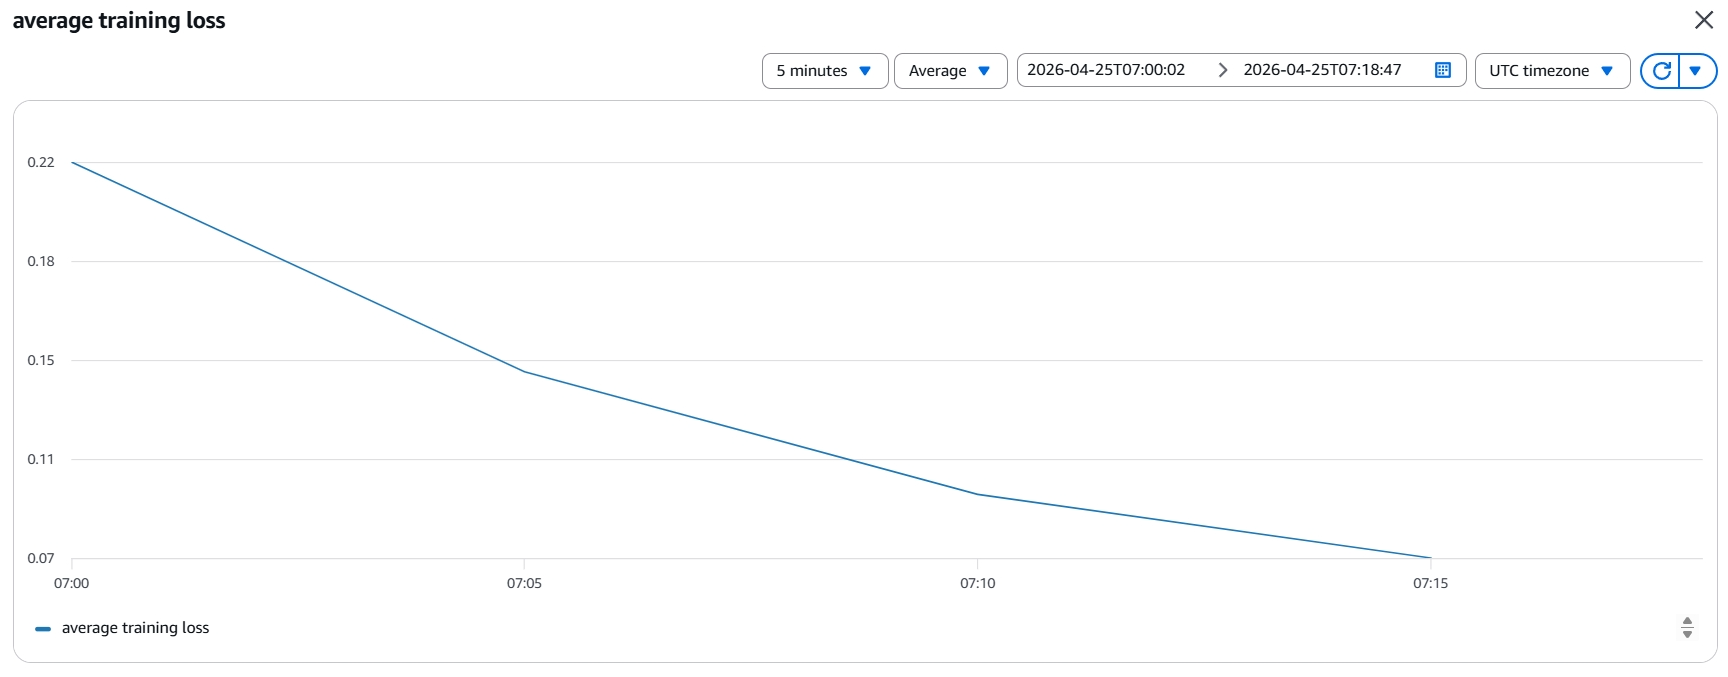

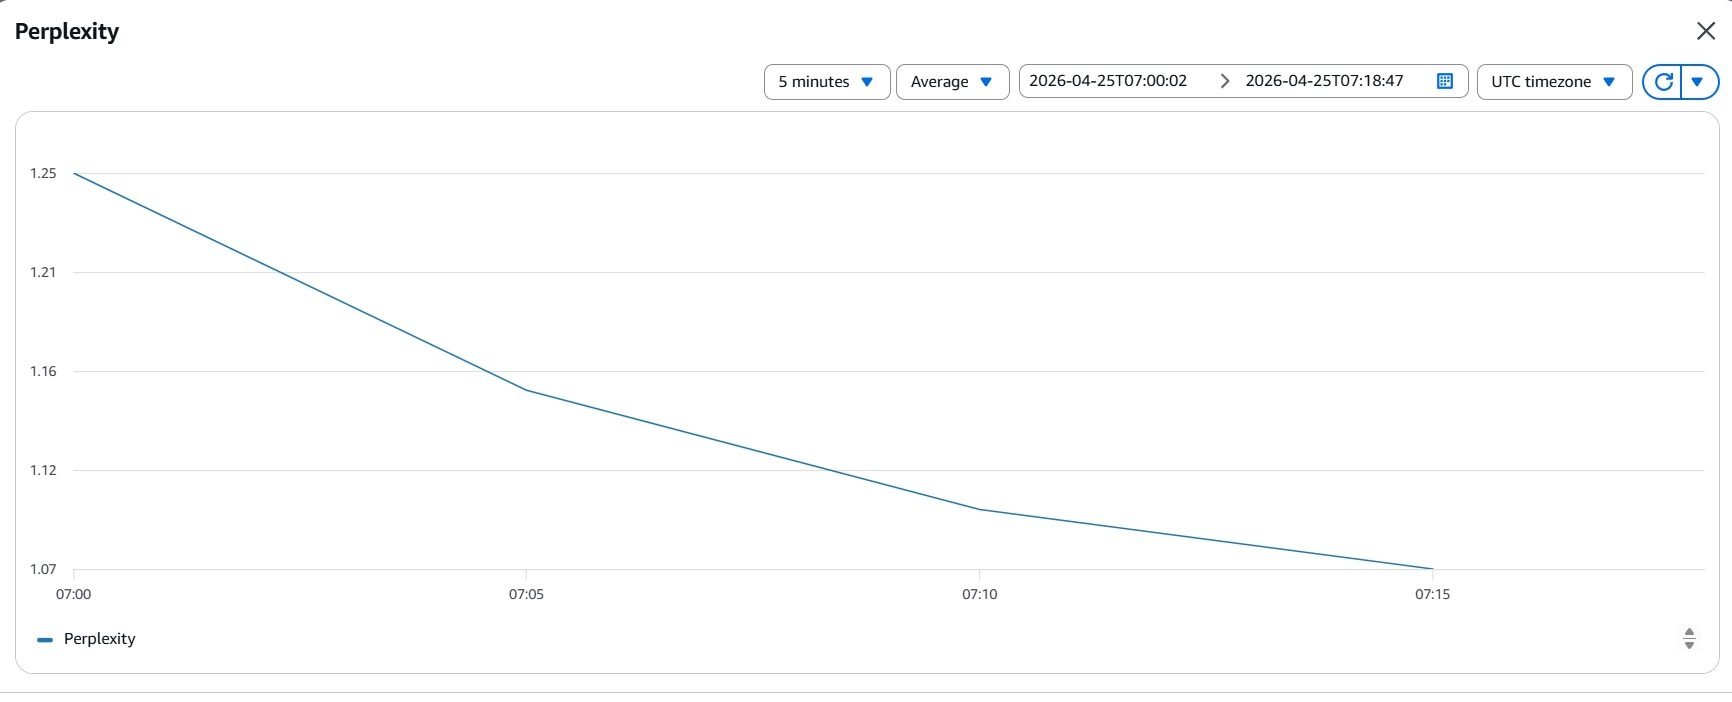

In [114]:
CKPT_DIR = './model_ckpts'
os.makedirs(CKPT_DIR, exist_ok=True)

In [115]:
!aws s3 cp {est_brogpt.model_data} {CKPT_DIR}/

download: s3://sagemaker-us-east-1-191013407134/brogpt-train-2026-04-25-06-59-20-750/output/model.tar.gz to model_ckpts/model.tar.gz


In [116]:
!aws s3 ls {est_brogpt.model_data}

2026-04-25 07:18:40  268078461 model.tar.gz


In [117]:
%cd {CKPT_DIR}

/home/ec2-user/SageMaker/CURRENTFOCUS/LLMS_transformers_WIP/LLMfromScratch/broGPT/model_ckpts


In [118]:
%pwd
!ls -ltrh

total 418M
-rw-r--r-- 1 ec2-user ec2-user  56M Feb 23  2025 ckpt_Epoch_100_Prplxty_1.0083447968191865.pt
-rw-rw-r-- 1 ec2-user ec2-user  51M Feb 23  2025 model_old.tar.gz
-rw-r--r-- 1 ec2-user ec2-user  56M Apr 25 06:31 ckpt_Epoch_50_Prplxty_1.010824581177966.pt
-rw-rw-r-- 1 ec2-user ec2-user 256M Apr 25 07:18 model.tar.gz


In [119]:
!gunzip -dc model.tar.gz |tar xvf -

tar: Ignoring unknown extended header keyword `LIBARCHIVE.creationtime'
ckpt_Epoch_40_Prplxty_1.0619401693860067.pt


In [120]:
!ls -ltrh

total 768M
-rw-r--r-- 1 ec2-user ec2-user  56M Feb 23  2025 ckpt_Epoch_100_Prplxty_1.0083447968191865.pt
-rw-rw-r-- 1 ec2-user ec2-user  51M Feb 23  2025 model_old.tar.gz
-rw-r--r-- 1 ec2-user ec2-user  56M Apr 25 06:31 ckpt_Epoch_50_Prplxty_1.010824581177966.pt
-rw-r--r-- 1 ec2-user ec2-user 351M Apr 25 07:18 ckpt_Epoch_40_Prplxty_1.0619401693860067.pt
-rw-rw-r-- 1 ec2-user ec2-user 256M Apr 25 07:18 model.tar.gz


In [121]:
hparams

{'bs': 32,
 'lrate': 0.0006,
 'num_epochs': 100,
 'do': 0.1,
 'block_size': 256,
 'environ': 'aws',
 'num_layers': 6,
 'num_heads': 4,
 'embed_dim': 256,
 'k_dim': 64,
 'ctx_len': 256}

In [122]:
tokenizer.vocab_size

50257

In [123]:
model = BroGPT(6, 4, 50257, 256, 64, 256, 0.1, device)

In [124]:
model.to(device)

BroGPT(
  (emb): Embed(
    (tok_layer): Embedding(50257, 256)
    (pos_layer): Embedding(256, 256)
    (norm_do): Sequential(
      (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (1): Dropout(p=0.1, inplace=False)
    )
  )
  (layers): Sequential(
    (0): Transformer_Block(
      (MHA): Attention_Block(
        (heads): ModuleList(
          (0-3): 4 x Attention(
            (query): Linear(in_features=256, out_features=64, bias=True)
            (key): Linear(in_features=256, out_features=64, bias=True)
            (value): Linear(in_features=256, out_features=64, bias=True)
            (att_do): Dropout(p=0.1, inplace=False)
          )
        )
        (lin_do): Sequential(
          (0): Linear(in_features=256, out_features=256, bias=True)
          (1): Dropout(p=0.1, inplace=False)
        )
      )
      (ff): Sequential(
        (0): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
        (1): Linear(in_features=256, out_features=1024, bias=True)
    

In [125]:
with open("./ckpt_Epoch_40_Prplxty_1.0619401693860067.pt", 'rb') as f:
    checkpoint = torch.load(f, map_location=torch.device(device))
    print(f'checkpoint keys: {checkpoint.keys()}')
    model.load_state_dict(checkpoint['model_state_dict'])
    print("completed success")

checkpoint keys: dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'loss', 'device'])
completed success


In [126]:
!head -15 ../shakes_ds.txt 

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.



In [127]:
def generate_toks(model, tokenizer, device, prompt, num_toks):
    gen_list = []
    orig_prompt = prompt
    model.to(device)
    for i in range(num_toks):
        input_ids = tokenizer.encode(prompt, return_tensors='pt')
        input_ids = input_ids.to(device)
        out = model(input_ids)
        ids = torch.argmax(out, dim=-1)
        gen_tok = ids[:,-1]
        dec = tokenizer.decode(gen_tok.squeeze().tolist())
        gen_list.append(dec)
        prompt = prompt + " " + dec
    print(f"Original Prompt: {orig_prompt}")
    print(f"Original + Generated Prompt: {prompt}")
    return orig_prompt, prompt


In [128]:
prompt = "First Citizen \n"
num_toks = 100
prompt, num_toks

('First Citizen \n', 100)

In [129]:
generate_toks(model, tokenizer, device, prompt, num_toks)

Original Prompt: First Citizen 

Original + Generated Prompt: First Citizen 
  to  use .  the  d oth .  the  hands  is  an  cam illing  friend , The  injury  of  victory . , url ;  him  to  the  ship  Could  you , en vious  ' tis  the  right .  the  wreck  and  raise  his  punishment  to  his  humble  and  the  Sixth  and  oldest  the  Duke  of  the  d oth .  for  the  fire :  his  wit  and  the  one  thing , im ; .  you ,  and  the  sound ly  to  the  greater  victory .  the  Tower .  the  gates  with  the  course ,  asking  your  stiff  good  seconds  To  the  d


('First Citizen \n',
 "First Citizen \n  to  use .  the  d oth .  the  hands  is  an  cam illing  friend , The  injury  of  victory . , url ;  him  to  the  ship  Could  you , en vious  ' tis  the  right .  the  wreck  and  raise  his  punishment  to  his  humble  and  the  Sixth  and  oldest  the  Duke  of  the  d oth .  for  the  fire :  his  wit  and  the  one  thing , im ; .  you ,  and  the  sound ly  to  the  greater  victory .  the  Tower .  the  gates  with  the  course ,  asking  your  stiff  good  seconds  To  the  d")

As we can see from above generated text, model is generating text that is similar to found in shakespear'ean language though not necessarily coherent. Next we will fine tune a pretrained language model